# 0: Task 1: Tabular Data (Adult Income)

Objective: Predict Whether Income Exceeds $50K / Year

Dataset Source: https://archive.ics.uci.edu/dataset/2/adult

## 1. Importing the Required Libraries

In [45]:
# Dataset fetching libraries
from ucimlrepo import fetch_ucirepo 

# Data processing libraries
import gzip
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Classical ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score
from sklearn.compose import make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import RocCurveDisplay

# Neural network import
import tensorflow as tf
# ML Explainability
from lime.lime_tabular import LimeTabularExplainer


## 2. Fetching the Dataset as a Pandas DataFrame

In [73]:
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 

## 3. Performing Exploratory Data Analysis

### 3.1 Viewing the Dataset Features - Overview

In [75]:
X.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States


### 3.2 Viewing the target Variable

### 3.2.1 Viewing the number of rows

In [4]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


### 3.2.2 Visualizing the distribution of the target variable

[Text(0, 0, '24720'),
 Text(0, 0, '7841'),
 Text(0, 0, '12435'),
 Text(0, 0, '3846')]

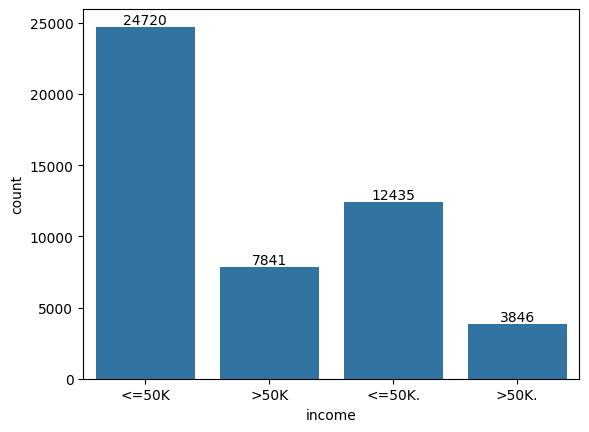

In [5]:
ax=sns.countplot(x='income',data=y)
ax.bar_label(ax.containers[0])

### 3.2.3 Checking data types of the features

In [6]:
pd.DataFrame({'Data type': X.dtypes}).T

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
Data type,int64,object,int64,object,int64,object,object,object,object,object,int64,int64,int64,object


### 3.2.4 Checking for Missing Values

In [7]:
pd.DataFrame({'% missing values': X.isnull().sum()*100 /len(X)}).T

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
% missing values,0.0,1.971664,0.0,0.0,0.0,0.0,1.977806,0.0,0.0,0.0,0.0,0.0,0.0,0.560993


## 4. Data Preparation

### 4.1 Data Preprocessing

#### 4.1.1 Data Transformation - Features

##### 4.1.1.1 Encoding Categorical Data to Numerical

In [8]:
categorical_cols = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']
# Drop the categorical columns
new_X=X.drop(columns=categorical_cols, axis=1)
# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
# Fit and transform the data
X_encoded = encoder.fit_transform(X[categorical_cols]).astype(int)

# Recreate the dataset with the encoded columns
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
encoded_X = pd.concat([new_X.reset_index(drop=True), X_encoded_df], axis=1)

##### 4.1.1.2 Inspect the Encoded dataset

In [9]:
encoded_X

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,215419,13,0,0,36,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
48838,64,321403,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
48839,38,374983,13,0,0,50,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
48840,44,83891,13,5455,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


##### 4.1.1.3 Impute the Missing Values using Mean

In [10]:
imputer = SimpleImputer(missing_values = np.nan,strategy ='mean')

In [11]:
imputer =imputer.fit(X_encoded)
X = imputer.transform(X_encoded)

#### 4.1.2 Data Transformation - Target Variable

##### 4.1.2.1 Remove any unwanted characters

In [12]:
y.loc[:, 'income'] = y['income'].str.replace('.', '', regex=False)

##### 4.1.2.2 Turning the target field to a binary classification field

In [13]:
y['bin'] = y.loc[:, 'income'].apply(lambda x: 1 if x =='>50K' else 0).astype(int)

/tmp/ipykernel_16538/2399472808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['bin'] = y.loc[:, 'income'].apply(lambda x: 1 if x =='>50K' else 0).astype(int)


In [14]:
y=y.drop('income',axis=1)

### 4.2 Data Preparation

#### 4.2.1 Split the data into training and testing set

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,random_state=0)

#### 4.2.2 Inspecting the training and testing set

In [16]:
X_train.shape,X_test.shape

((34189, 105), (14653, 105))

#### 4.2.3 Scale the data

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model Training and Evaluation

### 5.1 Classical Machine Learning Algorithms

#### 5.1 Training and Evaluating a Logistic Regression Model

##### 5.1.1 Training the Model

In [18]:
LR_Model=LogisticRegression(solver='liblinear', random_state=42)

In [19]:
LR_Model.fit(X_train_scaled,y_train)

/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


##### 5.1.2 Evaluating the Model

In [20]:
y_proba_LR=LR_Model.predict_proba(X_test)
y_pred_LR=LR_Model.predict(X_test)

In [21]:
LR_scores={
    'Model':'Logistic Regression',
    'roc_auc_score': roc_auc_score(y_test,y_proba_LR[:,1]),
    'accuracy_score': accuracy_score(y_test,y_pred_LR),
    'precision_score': precision_score(y_test,y_pred_LR,average="binary", pos_label=1),
    'recall_score': recall_score(y_test,y_pred_LR,average="binary", pos_label=1),
    'f1_score': f1_score(y_test,y_pred_LR,average="binary", pos_label=1)
}
LR_scores

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'Logistic Regression',
 'roc_auc_score': 0.8662773313061106,
 'accuracy_score': 0.7643485975568143,
 'precision_score': 0.0,
 'recall_score': 0.0,
 'f1_score': 0.0}

#### 5.2 Training and Evaluating a Decision Tree Model

##### 5.2.1 Training the Model

In [22]:
DTC_Model=DecisionTreeClassifier(random_state=1)

In [23]:
DTC_Model.fit(X_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### 5.2.2 Evaluating the Model

In [24]:
y_proba_DTC=DTC_Model.predict_proba(X_test)
y_pred_DTC=DTC_Model.predict(X_test)

In [25]:
DTC_scores={
    'Model': 'Decision Tree',
    'roc_auc_score': roc_auc_score(y_test,y_proba_DTC[:,1]),
    'accuracy_score': accuracy_score(y_test,y_pred_DTC),
    'precision_score': precision_score(y_test,y_pred_DTC,average="binary", pos_label=1),
    'recall_score': recall_score(y_test,y_pred_DTC,average="binary", pos_label=1),
    'f1_score': f1_score(y_test,y_pred_DTC,average="binary", pos_label=1)
}
DTC_scores

{'Model': 'Decision Tree',
 'roc_auc_score': 0.686313350709528,
 'accuracy_score': 0.7679656043131099,
 'precision_score': 0.673202614379085,
 'recall_score': 0.029829134086301768,
 'f1_score': 0.05712701053799223}

#### 5.3 Training and Evaluating a Random Forest Classifier Model

##### 5.3.1 Training the Model

In [26]:
RF_Model = RandomForestClassifier(n_estimators=100, random_state=42)

In [27]:
RF_Model.fit(X_train_scaled,y_train)

/opt/conda/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### 5.3.2 Evaluating the Model

In [28]:
y_proba_RF=RF_Model.predict_proba(X_test)
y_pred_RF=RF_Model.predict(X_test)

In [29]:
RF_scores={
    'Model': 'Random Forest',
    'roc_auc_score': roc_auc_score(y_test,y_proba_RF[:,1]),
    'accuracy_score': accuracy_score(y_test,y_pred_RF),
    'precision_score': precision_score(y_test,y_pred_RF,average="binary", pos_label=1),
    'recall_score': recall_score(y_test,y_pred_RF,average="binary", pos_label=1),
    'f1_score': f1_score(y_test,y_pred_RF,average="binary", pos_label=1)
}
RF_scores

{'Model': 'Random Forest',
 'roc_auc_score': 0.800552999979314,
 'accuracy_score': 0.7903500989558452,
 'precision_score': 0.681255946717412,
 'recall_score': 0.20735592238633072,
 'f1_score': 0.31793960923623443}

#### 5.4 Training and Evaluating a Gradient Boosting Classifier Model

##### 5.4.1 Training the Model

In [30]:
GBC_Model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

In [31]:
GBC_Model.fit(X_train_scaled,y_train)

/opt/conda/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,1.0
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,1
,min_impurity_decrease,0.0
,init,None


##### 5.4.2 Evaluating the Model

In [32]:
y_proba_GBC=GBC_Model.predict_proba(X_test)
y_pred_GBC=GBC_Model.predict(X_test)

In [33]:
GBC_scores={
    'Model': 'Gradient Boosting',
    'roc_auc_score': roc_auc_score(y_test,y_proba_GBC[:,1]),
    'accuracy_score': accuracy_score(y_test,y_pred_GBC),
    'precision_score': precision_score(y_test,y_pred_GBC,average="binary", pos_label=1),
    'recall_score': recall_score(y_test,y_pred_GBC,average="binary", pos_label=1),
    'f1_score': f1_score(y_test,y_pred_GBC,average="binary", pos_label=1)
}
GBC_scores

{'Model': 'Gradient Boosting',
 'roc_auc_score': 0.8200627947747301,
 'accuracy_score': 0.7642803521463182,
 'precision_score': 0.0,
 'recall_score': 0.0,
 'f1_score': 0.0}

#### 5.5 Best Performing Classical Model

#### 5.5.1 Model Performance Evaluation

In [34]:
data=[LR_scores,DTC_scores,RF_scores,GBC_scores]

In [35]:
score_comparison=pd.DataFrame(data)

In [36]:
score_comparison

,Model,roc_auc_score,accuracy_score,precision_score,recall_score,f1_score
0,Logistic Regression,0.866277,0.764349,0.000000,0.000000,0.000000
1,Decision Tree,0.686313,0.767966,0.673203,0.029829,0.057127
2,Random Forest,0.800553,0.790350,0.681256,0.207356,0.317940
3,Gradient Boosting,0.820063,0.764280,0.000000,0.000000,0.000000


#### 5.5.2 ROC Curve for the best perfoming classical Model

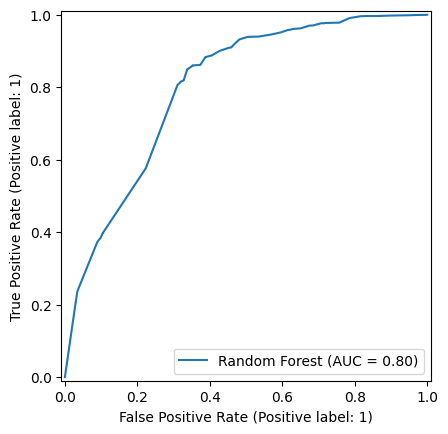

In [37]:
ax = plt.gca()
RocCurveDisplay.from_estimator(RF_Model, X_test, y_test, ax=ax, name='Random Forest')
plt.show()

## 6. Artificial Neural Networks

### 6.1 Training the Model

In [38]:
 # Initialize the model
model= tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])


/opt/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-08 02:03:21.627040: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [39]:
# Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
# Train the model
model.fit(X_train_scaled,y_train,epochs=1)

1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8163 - loss: 0.3880


### 6.2 Evaluating the Model

In [40]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
accuracy

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8287 - loss: 0.3645


0.8287039995193481

### 6.3 Comparison against Classical ML Models

In [41]:
ANN_scores={
    'Model': 'Artificial Neural Network',
    'accuracy_score': accuracy,
}
ANN_scores

{'Model': 'Artificial Neural Network', 'accuracy_score': 0.8287039995193481}

In [42]:
data=[LR_scores,DTC_scores,RF_scores,GBC_scores,ANN_scores]
score_comparison=pd.DataFrame(data)
score_comparison

,Model,roc_auc_score,accuracy_score,precision_score,recall_score,f1_score
0,Logistic Regression,0.866277,0.764349,0.000000,0.000000,0.000000
1,Decision Tree,0.686313,0.767966,0.673203,0.029829,0.057127
2,Random Forest,0.800553,0.790350,0.681256,0.207356,0.317940
3,Gradient Boosting,0.820063,0.764280,0.000000,0.000000,0.000000
4,Artificial Neural Network,NaN,0.828704,NaN,NaN,NaN


## 7. Feature Importance - LIME

In [67]:
feature_names=[]
for i in range(X_train.shape[1]):
    feature_names.append(encoded_X.columns[i])
    
class_names=['>50K','<=50K']

In [68]:
explainer = LimeTabularExplainer(training_data=X_train, feature_names=feature_names,class_names=class_names,
            mode='classification'
)

In [69]:
 # Choose an instance to explain
instance_to_explain = X_test[1]

explanation = explainer.explain_instance(
        data_row=instance_to_explain,
        predict_fn=RF_Model.predict_proba,
        num_features=5  # Number of top features to display
)

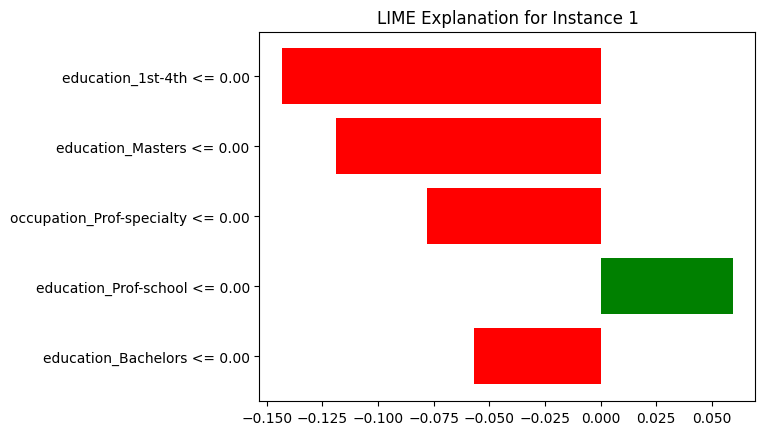

In [70]:
explanation.as_pyplot_figure()
plt.title(f"LIME Explanation for Instance {1}")
plt.show()

In [ ]:
feature_names

## 8. Clustering: K - Means Clusters

In [63]:
# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')

# Fit the model to the data
kmeans.fit(encoded_X)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

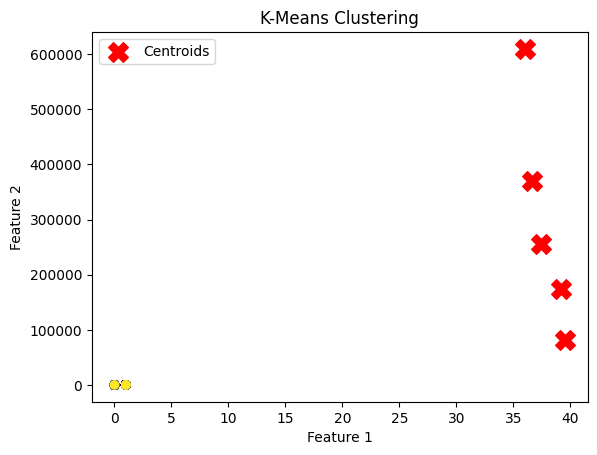

In [64]:
# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 9. Summary

This notebook applies classical and deep learning models to a tabular dataset. The tabular dataset contains adult income levels categorized as above or below $50K. To perform predictions based on the dataset features the following models were applied
- Classical Supervised Models
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Gradient Model
- Classical Unsupervised Models
      - K-means Clustering

- Deep Learning Models
      - Artificial Neural Networks

The best performing classical model was the Random Forest Model which achieved an accuracy level of 79%
- The ROC AUC score was at 0.80 which means that provided negative and positive samples, the model is able to correctly            identify positive values 80% of the time meaning that the model is a good fit for the provided dataset.
- From the AUC Curve, the model's curve behaviour start at 0,0 exhibiting a quick and fair rise meaning correct positive           sample identification. It also stays well within the diagonal meaning that the prediction is not random
- The most important features interpreted through lime are found to be age, education and workclass
    
The artificial neural network achieved the highest accuracy level of 82%
